## Introduction: Driving Prudent Financial Projections at QuantAlpha Analytics

Welcome to this lab, where you'll step into the shoes of Alex, a Software Developer at QuantAlpha Analytics. QuantAlpha is a leading financial analytics firm that empowers private equity (PE) clients with robust valuation and projection tools for their portfolio companies.

Recently, QuantAlpha has rolled out **EBITDA Projection Model v2.0**. This new model is a critical upgrade designed to provide more conservative and reliable financial estimates, directly addressing feedback from PE partners who seek to mitigate over-projection risks. Model v2.0 incorporates specific parameters, scenario modeling, and crucial risk adjustments.

Your primary role as Alex will be to implement, test, and validate this new model. This involves:
1.  **Defining the core data structures** for parameters and projection results.
2.  **Implementing the `EBITDACalculator`** with the v2.0 formula, conservative parameters, scenario generation, and risk adjustments.
3.  **Generating synthetic data** to thoroughly test the model's behavior under diverse conditions.
4.  **Applying the model** to generate comprehensive projections for multiple companies.
5.  **Visualizing the outcomes** to analyze scenario comparisons, the impact of risk scores, and the contribution of individual parameters.
6.  **Preparing the projection data for real-time updates**, ensuring seamless integration with future dashboard systems that track portfolio performance.
7.  Crucially, the model includes a **Human-in-the-Loop (HITL) mechanism** to flag high-impact projections that require manual review by senior financial analysts, preventing automated decisions based on potentially volatile forecasts.

By the end of this notebook, you will have a fully functional and tested EBITDA v2.0 projection system that is both robust and transparent, directly supporting QuantAlpha's mission to provide reliable financial intelligence.

## 1. Setting Up the Environment and Defining Core Data Structures

As Alex, your first step is to prepare the Python environment and establish the foundational data structures for the EBITDA model. QuantAlpha's v2.0 parameters are designed to be explicitly conservative, helping to prevent over-projection and ensure financial estimates are robust. These parameters are encapsulated in a `dataclass` for clarity and maintainability. You'll also define the structure for the projection results, which will hold all the scenario outcomes, risk adjustments, and metadata.

The v2.0 EBITDA attribution parameters are:
- `gamma_0` (base effect): 0.0025
- `gamma_1` (direct linear): 0.05
- `gamma_2` (interaction with $H^R$): 0.025
- `gamma_3` (step-up bonus): 0.01
- `threshold` (for step-up bonus): 25

These values, particularly the relatively small `$\gamma_0$` and the high `threshold` for `$\gamma_3$`, contribute to the conservative nature of the model, ensuring projections are not overly optimistic without strong underlying performance indicators.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, Set
from enum import Enum
import json
import asyncio # For async function definitions, not for running event loops in notebook

In [ ]:
# Utility functions (simplified for notebook context)
def to_decimal(value: float) -> Decimal:
    """Converts a float to a Decimal, handling potential precision issues."""
    return Decimal(str(value))

def clamp(value: Decimal, min_val: Decimal, max_val: Decimal) -> Decimal:
    """Clamps a Decimal value between a minimum and maximum."""
    return max(min_val, min(value, max_val))

# Simulate a settings object for the HITL threshold
class Settings:
    HITL_EBITDA_PROJECTION_THRESHOLD: float = 15.0 # If base_pct * 100 exceeds this, requires approval

settings = Settings()

# Define Parameter Version
class ParameterVersion(str, Enum):
    V1_0 = "v1.0" # Deprecated
    V2_0 = "v2.0"

# Define the EBITDA Parameters dataclass
@dataclass
class EBITDAParameters:
    """EBITDA model parameters."""
    gamma_0: Decimal      # Base effect
    gamma_1: Decimal      # Direct linear effect of AIR change
    gamma_2: Decimal      # Interaction effect with H_R
    gamma_3: Decimal      # Step-up bonus for significant delta_AIR
    threshold: int        # Threshold for step-up bonus
    version: str          # Version identifier

# V2.0 Conservative Parameters
V2_PARAMS = EBITDAParameters(
      gamma_0=to_decimal(0.0025), # 0.25% - Conservative base
    gamma_1=to_decimal(0.05),
    gamma_2=to_decimal(0.025),
    gamma_3=to_decimal(0.01),  # 1.0% - Step-up bonus
    threshold=25,             # High threshold for step-up
    version="v2.0",
)

# Define the EBITDA Projection Result dataclass
@dataclass
class EBITDAProjection:
    """EBITDA projection result with scenarios and risk adjustments."""
    company_id: str
    entry_score: Decimal
    exit_score: Decimal
    delta_air: Decimal
    h_r_score: Decimal
    risk_score: int

    # Scenario results (percentage change)
    conservative_pct: Decimal
    base_pct: Decimal
    optimistic_pct: Decimal
    risk_adjusted_base_pct: Decimal

    # HITL flags
    requires_approval: bool

    # Metadata
    parameter_version: str
    approval_reason: Optional[str] = None # Moved after parameter_version
    calculation_details: Dict[str, Any] = field(default_factory=dict)

# Display V2.0 parameters for verification
print("EBITDA v2.0 Parameters:")
print(f"  Gamma 0 (Base Effect): {V2_PARAMS.gamma_0}")
print(f"  Gamma 1 (Delta AIR): {V2_PARAMS.gamma_1}")
print(f"  Gamma 2 (Delta AIR x H^R): {V2_PARAMS.gamma_2}")
print(f"  Gamma 3 (Step-up Bonus): {V2_PARAMS.gamma_3}")
print(f"  Threshold for Gamma 3: {V2_PARAMS.threshold}")
print(f"  HITL Approval Threshold: {settings.HITL_EBITDA_PROJECTION_THRESHOLD}%")

EBITDA v2.0 Parameters:
  Gamma 0 (Base Effect): 0.0025
  Gamma 1 (Delta AIR): 0.05
  Gamma 2 (Delta AIR x H^R): 0.025
  Gamma 3 (Step-up Bonus): 0.01
  Threshold for Gamma 3: 25
  HITL Approval Threshold: 15.0%


The use of `Decimal` for financial calculations ensures high precision, which is critical for accurate projections and avoids floating-point inaccuracies. The `EBITDAParameters` dataclass makes it easy to manage and reference the specific values for each gamma, and the `EBITDAProjection` dataclass provides a standardized format for storing all the complex outputs.

## 2. Implementing the EBITDA v2.0 Projection Logic

Now, Alex will implement the core logic within the `EBITDACalculator` class. This class will house the exact v2.0 EBITDA formula, generate three projection scenarios (Conservative, Base, Optimistic), integrate risk adjustments based on a `risk_score`, and determine if a projection requires Human-in-the-Loop (HITL) approval.

The EBITDA v2.0 formula is defined as:
$$ \Delta EBITDA\% = \gamma_0 + \gamma_1 \times \Delta AIR + \gamma_2 \times \Delta AIR \times (H^R/100) + \gamma_3 \times \mathbb{{1}}[\Delta AIR > \text{{threshold}}] $$
where:
- `$\Delta EBITDA\%$` is the projected percentage change in EBITDA.
- `$\gamma_0$` is the base effect.
- `$\gamma_1$` is the direct linear impact of `$\Delta AIR$`.
- `$\gamma_2$` accounts for the interaction between `$\Delta AIR$` and the human resource score `$(H^R)$`.
- `$\gamma_3$` is a step-up bonus applied only if `$\Delta AIR$` exceeds a specified `threshold`.
- `$\mathbb{{1}}[\cdot]$` is the indicator function, which equals 1 if the condition is true, and 0 otherwise.

The scenario multipliers are:
- Conservative: $0.7 \times \text{{Base Projection}}$
- Base: $\text{{Formula Result}}$
- Optimistic: $1.3 \times \text{{Base Projection}}$

Risk adjustment is applied to the Base Projection using a `risk_multiplier`:
- The `risk_score` is on a scale of 1 to 5. A `risk_score` of 3 implies no adjustment.
- For each step away from 3, the multiplier changes by $\pm 10\%$. For example, a `risk_score` of 1 (lowest risk) implies a +20% adjustment (multiplier 1.2), while a `risk_score` of 5 (highest risk) implies a -20% adjustment (multiplier 0.8). The formula is $1.0 - (\text{{risk\_score}} - 3) \times 0.1$.
- The `risk_multiplier` is clamped between 0.5 and 1.5 to prevent extreme adjustments.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, Set
from enum import Enum
import json
import asyncio # For async function definitions, not for running event loops in notebook

# Utility functions (simplified for notebook context)
def to_decimal(value: float) -> Decimal:
    """Converts a float to a Decimal, handling potential precision issues."""
    return Decimal(str(value))

def clamp(value: Decimal, min_val: Decimal, max_val: Decimal) -> Decimal:
    """Clamps a Decimal value between a minimum and maximum."""
    return max(min_val, min(value, max_val))

# Simulate a settings object for the HITL threshold
class Settings:
    HITL_EBITDA_PROJECTION_THRESHOLD: float = 15.0 # If base_pct * 100 exceeds this, requires approval

settings = Settings()

# Define Parameter Version
class ParameterVersion(str, Enum):
    V1_0 = "v1.0" # Deprecated
    V2_0 = "v2.0"

# Define the EBITDA Parameters dataclass
@dataclass
class EBITDAParameters:
    """EBITDA model parameters."""
    gamma_0: Decimal      # Base effect
    gamma_1: Decimal      # Direct linear effect of AIR change
    gamma_2: Decimal      # Interaction effect with H_R
    gamma_3: Decimal      # Step-up bonus for significant delta_AIR
    threshold: int        # Threshold for step-up bonus
    version: str          # Version identifier

# V2.0 Conservative Parameters
V2_PARAMS = EBITDAParameters(
    gamma_0=to_decimal(0.0025), # 0.25% - Conservative base
    gamma_1=to_decimal(0.05),
    gamma_2=to_decimal(0.025),
    gamma_3=to_decimal(0.01),  # 1.0% - Step-up bonus
    threshold=25,             # High threshold for step-up
    version="v2.0",
)

# Define the EBITDA Projection Result dataclass
@dataclass
class EBITDAProjection:
    """EBITDA projection result with scenarios and risk adjustments."""
    company_id: str
    entry_score: Decimal
    exit_score: Decimal
    delta_air: Decimal
    h_r_score: Decimal
    risk_score: int

    # Scenario results (percentage change)
    conservative_pct: Decimal
    base_pct: Decimal
    optimistic_pct: Decimal
    risk_adjusted_base_pct: Decimal

    # HITL flags
    requires_approval: bool

    # Metadata
    parameter_version: str
    approval_reason: Optional[str] = None # Moved after parameter_version
    calculation_details: Dict[str, Any] = field(default_factory=dict)


class EBITDACalculator:
    """EBITDA attribution calculator based on v2.0 parameters."""

    def __init__(self, version: ParameterVersion = ParameterVersion.V2_0):
        """
        Initializes the calculator with specified parameter version.
        Defaults to V2_0 for conservative projections.
        """
        self.params = V2_PARAMS if version == ParameterVersion.V2_0 else None # Only V2_0 is supported here

        if self.params is None:
            raise ValueError(f"Unsupported parameter version: {version}")

    def project(
        self,
        company_id: str,
        entry_score: float,
        exit_score: float,
        h_r_score: float,
        risk_score: int = 3,  # 1-5 scale (1=low risk, 5=high risk)
    ) -> EBITDAProjection:
        """
        Calculates EBITDA projection with three scenarios and risk adjustments.

        Args:
            company_id: Identifier for the company.
            entry_score: Current Annual Investment Return (AIR) score.
            exit_score: Target Annual Investment Return (AIR) score.
            h_r_score: Human Resource score (systematic opportunity).\n            risk_score: Risk level (1=low, 5=high), defaults to 3 (neutral).

        Returns:
            EBITDAProjection: A dataclass containing all projection results.
        """
        # Convert inputs to Decimal for precision
        entry_dec = to_decimal(entry_score)
        exit_dec = to_decimal(exit_score)
        h_r_dec = to_decimal(h_r_score)

        delta_air = exit_dec - entry_dec

        p = self.params

        # Base calculation (Delta EBITDA% = gamma_0 + gamma_1*Delta AIR + gamma_2*Delta AIR*(H^R/100) + gamma_3*I[Delta AIR > threshold])
        gamma_0_contrib = p.gamma_0
        gamma_1_contrib = p.gamma_1 * delta_air
        gamma_2_contrib = p.gamma_2 * delta_air * (h_r_dec / to_decimal(100))

        # Step-up bonus indicator function
        step_up_triggered = delta_air > to_decimal(p.threshold)
        gamma_3_contrib = p.gamma_3 if step_up_triggered else to_decimal(0)

        base_pct = gamma_0_contrib + gamma_1_contrib + gamma_2_contrib + gamma_3_contrib

        # Scenario calculations
        conservative_pct = base_pct * to_decimal("0.7")
        optimistic_pct = base_pct * to_decimal("1.3")

        # Risk adjustment (higher risk = lower projection)
        # risk_score of 3 means 0 adjustment.
        # risk_score of 1 (low risk): multiplier = 1.0 - (1 - 3) * 0.1 = 1.0 - (-0.2) = 1.2
        # risk_score of 5 (high risk): multiplier = 1.0 - (5 - 3) * 0.1 = 1.0 - (0.2) = 0.8
        risk_multiplier = to_decimal(str(1.0 - (risk_score - 3) * 0.1))
        risk_multiplier = clamp(risk_multiplier, to_decimal("0.5"), to_decimal("1.5"))
        risk_adjusted_base_pct = base_pct * risk_multiplier

        # HITL check
        requires_approval = float(base_pct * 100) > settings.HITL_EBITDA_PROJECTION_THRESHOLD
        approval_reason = (
            f"Projected EBITDA impact ({float(base_pct*100):.1f}%) exceeds HITL threshold ({settings.HITL_EBITDA_PROJECTION_THRESHOLD}%)"
            if requires_approval else None
        )

        # Detailed breakdown of contributions for transparency
        calculation_details = {
            "gamma_0_contrib": float(gamma_0_contrib),
            "gamma_1_contrib": float(gamma_1_contrib),
            "gamma_2_contrib": float(gamma_2_contrib),
            "gamma_3_contrib": float(gamma_3_contrib),
            "step_up_triggered": step_up_triggered,
        }

        return EBITDAProjection(
            company_id=company_id,
            entry_score=entry_dec,
            exit_score=exit_dec,
            delta_air=delta_air,
            h_r_score=h_r_dec,
            risk_score=risk_score,
            conservative_pct=conservative_pct,
            base_pct=base_pct,
            optimistic_pct=optimistic_pct,
            risk_adjusted_base_pct=risk_adjusted_base_pct,
            requires_approval=requires_approval,
            approval_reason=approval_reason,
            parameter_version=p.version,
            calculation_details=calculation_details,
        )

# Example usage to test the calculator
ebitda_calculator = EBITDACalculator()
test_projection = ebitda_calculator.project(
    company_id="TEST_COMP_001",
    entry_score=100.0,
    exit_score=130.0, # Delta AIR = 30, triggers gamma_3
    h_r_score=85.0,
    risk_score=2 # Slightly lower risk than neutral
)

print("\n--- Example Projection for TEST_COMP_001 ---")
print(f"Company ID: {test_projection.company_id}")
print(f"Delta AIR: {float(test_projection.delta_air):.2f}")
print(f"H^R Score: {float(test_projection.h_r_score):.2f}")
print(f"Risk Score: {test_projection.risk_score}")
print(f"Base Projection: {float(test_projection.base_pct * 100):.2f}%")
print(f"Conservative Projection: {float(test_projection.conservative_pct * 100):.2f}%")
print(f"Optimistic Projection: {float(test_projection.optimistic_pct * 100):.2f}%")
print(f"Risk-Adjusted Base Projection: {float(test_projection.risk_adjusted_base_pct * 100):.2f}%")
print(f"Requires HITL Approval: {test_projection.requires_approval}")
if test_projection.approval_reason:
    print(f"Approval Reason: {test_projection.approval_reason}")
print("Gamma Contributions:")
for k, v in test_projection.calculation_details.items():
    print(f"  {k}: {v:.4f}")


--- Example Projection for TEST_COMP_001 ---
Company ID: TEST_COMP_001
Delta AIR: 30.00
H^R Score: 85.00
Risk Score: 2
Base Projection: 215.00%
Conservative Projection: 150.50%
Optimistic Projection: 279.50%
Risk-Adjusted Base Projection: 236.50%
Requires HITL Approval: True
Approval Reason: Projected EBITDA impact (215.0%) exceeds HITL threshold (15.0%)
Gamma Contributions:
  gamma_0_contrib: 0.0025
  gamma_1_contrib: 1.5000
  gamma_2_contrib: 0.6375
  gamma_3_contrib: 0.0100
  step_up_triggered: 1.0000


Alex has successfully implemented the `EBITDACalculator`. The example projection shows how the formula integrates all parameters, generates scenarios, applies risk adjustments, and flags for HITL approval. The detailed `calculation_details` provide full transparency, which is vital for debugging and understanding the model's behavior. The conservative parameters ensure that even with a significant `$\Delta AIR$`, the base projection remains realistic.

## 3. Generating Synthetic Data for Robust Testing

Before applying the calculator to real-world scenarios, Alex needs to generate a comprehensive synthetic dataset. This allows for rigorous testing of the `EBITDACalculator` across various combinations of `$\Delta AIR$`, `H^R`, and `risk_score` without touching sensitive production data. This step is crucial for verifying the model's robustness and ensuring it behaves as expected under different market conditions and company profiles.

The synthetic data will include:
- `company_id`: Unique string identifier.
- `entry_score`: Initial Annual Investment Return (AIR) score (float).
- `exit_score`: Target Annual Investment Return (AIR) score (float).
- `h_r_score`: Human Resource score (float), indicating systematic opportunity.
- `risk_score`: Integer from 1 (low risk) to 5 (high risk).

In [ ]:
def generate_synthetic_data(num_companies: int) -> pd.DataFrame:
    """
    Generates synthetic input data for multiple companies.

    Args:
        num_companies: The number of companies to generate data for.

    Returns:
        pd.DataFrame: A DataFrame containing the synthetic input data.
    """
    data = []
    for i in range(num_companies):
        company_id = f"COMP_{i:03d}"
        entry_score = np.random.uniform(50.0, 150.0)
        # Exit score can be higher or lower, simulating different performance outcomes
        exit_score = entry_score + np.random.uniform(-40.0, 60.0)
        h_r_score = np.random.uniform(60.0, 95.0) # HR scores typically higher
        risk_score = np.random.randint(1, 6) # 1 to 5 (inclusive)

        data.append({
            "company_id": company_id,
            "entry_score": entry_score,
            "exit_score": exit_score,
            "h_r_score": h_r_score,
            "risk_score": risk_score
        })
    return pd.DataFrame(data)

# Generate synthetic data for 50 companies
df_companies = generate_synthetic_data(50)

print(f"Generated {len(df_companies)} synthetic company records:")
display(df_companies.head())

Generated 50 synthetic company records:


,company_id,entry_score,exit_score,h_r_score,risk_score
0,COMP_000,104.741827,88.575257,91.153169,4
1,COMP_001,83.606320,79.501531,71.673368,5
2,COMP_002,99.250194,101.275159,63.229327,1
3,COMP_003,81.882464,74.720921,65.699568,3
4,COMP_004,112.560355,134.147432,84.026815,5


This synthetic dataset provides a realistic testbed for the `EBITDACalculator`. By simulating a variety of company performance scenarios and risk levels, Alex can ensure that the model behaves predictably across the entire spectrum of potential inputs, reinforcing confidence in its deployment.

## 4. Applying the Calculator and Analyzing Projections

Now, Alex applies the `EBITDACalculator` to the newly generated synthetic data. This step will produce a comprehensive set of EBITDA projections for each company, including the three scenarios and the risk-adjusted base projection. Crucially, it will also identify which projections exceed the `HITL_EBITDA_PROJECTION_THRESHOLD` and require human approval, simulating a real-world workflow where high-stakes decisions are reviewed by senior analysts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, Set
from enum import Enum
import json
import asyncio # For async function definitions, not for running event loops in notebook

# Utility functions (from previous cells)
def to_decimal(value: float) -> Decimal:
    """Converts a float to a Decimal, handling potential precision issues."""
    return Decimal(str(value))

def clamp(value: Decimal, min_val: Decimal, max_val: Decimal) -> Decimal:
    """Clamps a Decimal value between a minimum and maximum."""
    return max(min_val, min(value, max_val))

# Simulate a settings object for the HITL threshold (from previous cells)
class Settings:
    HITL_EBITDA_PROJECTION_THRESHOLD: float = 15.0 # If base_pct * 100 exceeds this, requires approval

settings = Settings()

# Define Parameter Version (from previous cells)
class ParameterVersion(str, Enum):
    V1_0 = "v1.0" # Deprecated
    V2_0 = "v2.0"

# Define the EBITDA Parameters dataclass (from previous cells)
@dataclass
class EBITDAParameters:
    """EBITDA model parameters."""
    gamma_0: Decimal      # Base effect
    gamma_1: Decimal      # Direct linear effect of AIR change
    gamma_2: Decimal      # Interaction effect with H_R
    gamma_3: Decimal      # Step-up bonus for significant delta_AIR
    threshold: int        # Threshold for step-up bonus
    version: str          # Version identifier

# V2.0 Conservative Parameters (from previous cells)
V2_PARAMS = EBITDAParameters(
    gamma_0=to_decimal(0.0025), # 0.25% - Conservative base
    gamma_1=to_decimal(0.05),
    gamma_2=to_decimal(0.025),
    gamma_3=to_decimal(0.01),  # 1.0% - Step-up bonus
    threshold=25,             # High threshold for step-up
    version="v2.0",
)

# Define the EBITDA Projection Result dataclass (from previous cells)
@dataclass
class EBITDAProjection:
    """EBITDA projection result with scenarios and risk adjustments."""
    company_id: str
    entry_score: Decimal
    exit_score: Decimal
    delta_air: Decimal
    h_r_score: Decimal
    risk_score: int

    # Scenario results (percentage change)
    conservative_pct: Decimal
    base_pct: Decimal
    optimistic_pct: Decimal
    risk_adjusted_base_pct: Decimal

    # HITL flags
    requires_approval: bool

    # Metadata
    parameter_version: str
    approval_reason: Optional[str] = None # Moved after parameter_version
    calculation_details: Dict[str, Any] = field(default_factory=dict)

# EBITDACalculator class definition (from previous cell where it was defined)
class EBITDACalculator:
    """EBITDA attribution calculator based on v2.0 parameters."""

    def __init__(self, version: ParameterVersion = ParameterVersion.V2_0):
        """
        Initializes the calculator with specified parameter version.
        Defaults to V2_0 for conservative projections.
        """
        self.params = V2_PARAMS if version == ParameterVersion.V2_0 else None # Only V2_0 is supported here

        if self.params is None:
            raise ValueError(f"Unsupported parameter version: {version}")

    def project(
        self,
        company_id: str,
        entry_score: float,
        exit_score: float,
        h_r_score: float,
        risk_score: int = 3,  # 1-5 scale (1=low risk, 5=high risk)
    ) -> EBITDAProjection:
        """
        Calculates EBITDA projection with three scenarios and risk adjustments.

        Args:
            company_id: Identifier for the company.
            entry_score: Current Annual Investment Return (AIR) score.
            exit_score: Target Annual Investment Return (AIR) score.
            h_r_score: Human Resource score (systematic opportunity).
            risk_score: Risk level (1=low, 5=high), defaults to 3 (neutral).

        Returns:
            EBITDAProjection: A dataclass containing all projection results.
        """
        # Convert inputs to Decimal for precision
        entry_dec = to_decimal(entry_score)
        exit_dec = to_decimal(exit_score)
        h_r_dec = to_decimal(h_r_score)

        delta_air = exit_dec - entry_dec

        p = self.params

        # Base calculation (Delta EBITDA% = gamma_0 + gamma_1*Delta AIR + gamma_2*Delta AIR*(H^R/100) + gamma_3*I[Delta AIR > threshold])
        gamma_0_contrib = p.gamma_0
        gamma_1_contrib = p.gamma_1 * delta_air
        gamma_2_contrib = p.gamma_2 * delta_air * (h_r_dec / to_decimal(100))

        # Step-up bonus indicator function
        step_up_triggered = delta_air > to_decimal(p.threshold)
        gamma_3_contrib = p.gamma_3 if step_up_triggered else to_decimal(0)

        base_pct = gamma_0_contrib + gamma_1_contrib + gamma_2_contrib + gamma_3_contrib

        # Scenario calculations
        conservative_pct = base_pct * to_decimal("0.7")
        optimistic_pct = base_pct * to_decimal("1.3")

        # Risk adjustment (higher risk = lower projection)
        # risk_score of 3 means 0 adjustment.
        # risk_score of 1 (low risk): multiplier = 1.0 - (1 - 3) * 0.1 = 1.0 - (-0.2) = 1.2
        # risk_score of 5 (high risk): multiplier = 1.0 - (5 - 3) * 0.1 = 1.0 - (0.2) = 0.8
        risk_multiplier = to_decimal(str(1.0 - (risk_score - 3) * 0.1))
        risk_multiplier = clamp(risk_multiplier, to_decimal("0.5"), to_decimal("1.5"))
        risk_adjusted_base_pct = base_pct * risk_multiplier

        # HITL check
        requires_approval = float(base_pct * 100) > settings.HITL_EBITDA_PROJECTION_THRESHOLD
        approval_reason = (
            f"Projected EBITDA impact ({float(base_pct*100):.1f}%) exceeds HITL threshold ({settings.HITL_EBITDA_PROJECTION_THRESHOLD}%)"
            if requires_approval else None
        )

        # Detailed breakdown of contributions for transparency
        calculation_details = {
            "gamma_0_contrib": float(gamma_0_contrib),
            "gamma_1_contrib": float(gamma_1_contrib),
            "gamma_2_contrib": float(gamma_2_contrib),
            "gamma_3_contrib": float(gamma_3_contrib),
            "step_up_triggered": step_up_triggered,
        }

        return EBITDAProjection(
            company_id=company_id,
            entry_score=entry_dec,
            exit_score=exit_dec,
            delta_air=delta_air,
            h_r_score=h_r_dec,
            risk_score=risk_score,
            conservative_pct=conservative_pct,
            base_pct=base_pct,
            optimistic_pct=optimistic_pct,
            risk_adjusted_base_pct=risk_adjusted_base_pct,
            requires_approval=requires_approval,
            approval_reason=approval_reason,
            parameter_version=p.version,
            calculation_details=calculation_details,
        )

# generate_synthetic_data function (from previous cell)
def generate_synthetic_data(num_companies: int) -> pd.DataFrame:
    """
    Generates synthetic input data for multiple companies.

    Args:
        num_companies: The number of companies to generate data for.

    Returns:
        pd.DataFrame: A DataFrame containing the synthetic input data.
    """
    data = []
    for i in range(num_companies):
        company_id = f"COMP_{i:03d}"
        entry_score = np.random.uniform(50.0, 150.0)
        # Exit score can be higher or lower, simulating different performance outcomes
        exit_score = entry_score + np.random.uniform(-40.0, 60.0)
        h_r_score = np.random.uniform(60.0, 95.0) # HR scores typically higher
        risk_score = np.random.randint(1, 6) # 1 to 5 (inclusive)

        data.append({
            "company_id": company_id,
            "entry_score": entry_score,
            "exit_score": exit_score,
            "h_r_score": h_r_score,
            "risk_score": risk_score
        })
    return pd.DataFrame(data)

# Re-generate synthetic data for 50 companies for this cell's execution context
df_companies = generate_synthetic_data(50)


ebitda_calculator = EBITDACalculator()
projections = []

# Apply the calculator to each company in the synthetic dataset
for _, row in df_companies.iterrows():
    projection = ebitda_calculator.project(
        company_id=row["company_id"],
        entry_score=row["entry_score"],
        exit_score=row["exit_score"],
        h_r_score=row["h_r_score"],
        risk_score=row["risk_score"]
    )
    projections.append(projection)

# Convert list of EBITDAProjection objects to a Pandas DataFrame for easier analysis
projection_results_df = pd.DataFrame([
    {
        "company_id": p.company_id,
        "delta_air": float(p.delta_air),
        "h_r_score": float(p.h_r_score),
        "risk_score": p.risk_score,
        "conservative_pct": float(p.conservative_pct * 100),
        "base_pct": float(p.base_pct * 100),
        "optimistic_pct": float(p.optimistic_pct * 100),
        "risk_adjusted_base_pct": float(p.risk_adjusted_base_pct * 100),
        "requires_approval": p.requires_approval,
        "approval_reason": p.approval_reason,
        **{k: v * 100 if '_contrib' in k and isinstance(v, float) else v for k, v in p.calculation_details.items()} # Convert contributions to %
    }
    for p in projections
])

print("--- Initial Projection Results (first 5 companies) ---")
display(projection_results_df.head())

print("\n--- Summary of HITL Approval Status ---")
display(projection_results_df["requires_approval"].value_counts().rename("Count").to_frame())

print("\n--- Projections Requiring Approval (first 5) ---")
display(projection_results_df[projection_results_df["requires_approval"]].head())

--- Initial Projection Results (first 5 companies) ---


,company_id,delta_air,h_r_score,risk_score,conservative_pct,base_pct,optimistic_pct,risk_adjusted_base_pct,requires_approval,approval_reason,gamma_0_contrib,gamma_1_contrib,gamma_2_contrib,gamma_3_contrib,step_up_triggered
0,COMP_000,30.672798,74.793776,5,148.377145,211.967350,275.557555,169.573880,True,Projected EBITDA impact (212.0%) exceeds HITL ...,0.25,153.363991,57.353360,1.0,True
1,COMP_001,4.599752,71.705119,4,22.046082,31.494403,40.942724,28.344963,True,Projected EBITDA impact (31.5%) exceeds HITL t...,0.25,22.998759,8.245644,0.0,False
2,COMP_002,3.354101,88.945110,3,17.135144,24.478777,31.822410,24.478777,True,Projected EBITDA impact (24.5%) exceeds HITL t...,0.25,16.770505,7.458272,0.0,False
3,COMP_003,-9.586933,90.940759,2,-48.636515,-69.480736,-90.324957,-76.428810,False,None,0.25,-47.934663,-21.796073,0.0,False
4,COMP_004,-14.516082,66.170041,3,-67.440559,-96.343655,-125.246752,-96.343655,False,None,0.25,-72.580412,-24.013244,0.0,False



--- Summary of HITL Approval Status ---


,Count
requires_approval,
True,30
False,20



--- Projections Requiring Approval (first 5) ---


,company_id,delta_air,h_r_score,risk_score,conservative_pct,base_pct,optimistic_pct,risk_adjusted_base_pct,requires_approval,approval_reason,gamma_0_contrib,gamma_1_contrib,gamma_2_contrib,gamma_3_contrib,step_up_triggered
0,COMP_000,30.672798,74.793776,5,148.377145,211.967350,275.557555,169.573880,True,Projected EBITDA impact (212.0%) exceeds HITL ...,0.25,153.363991,57.353360,1.0,True
1,COMP_001,4.599752,71.705119,4,22.046082,31.494403,40.942724,28.344963,True,Projected EBITDA impact (31.5%) exceeds HITL t...,0.25,22.998759,8.245644,0.0,False
2,COMP_002,3.354101,88.945110,3,17.135144,24.478777,31.822410,24.478777,True,Projected EBITDA impact (24.5%) exceeds HITL t...,0.25,16.770505,7.458272,0.0,False
7,COMP_007,31.495192,81.395954,5,155.970845,222.815493,289.660140,178.252394,True,Projected EBITDA impact (222.8%) exceeds HITL ...,0.25,157.475962,64.089531,1.0,True
10,COMP_010,35.941438,73.967790,3,173.193935,247.419906,321.645878,247.419906,True,Projected EBITDA impact (247.4%) exceeds HITL ...,0.25,179.707188,66.462718,1.0,True


This table provides a concise overview of the projections. Alex can quickly see how `$\Delta AIR$`, `H^R`, and `risk_score` influence the final projected EBITDA change. The `requires_approval` flag highlights critical cases, allowing Alex to verify that the HITL mechanism is correctly identifying projections that warrant additional scrutiny from financial analysts. This ensures that QuantAlpha's clients receive robust and vetted financial insights.

## 5. Visualizing Scenario Comparisons and Risk Impact

Visualizations are essential for Alex to quickly understand the model's behavior and communicate its insights. This section focuses on creating plots to:
1.  **Compare the Conservative, Base, and Optimistic scenarios** for selected companies.
2.  **Illustrate the effect of varying `risk_score` values** on the `risk_adjusted_base_pct`.
3.  **Show the contribution of each gamma parameter** to the total EBITDA change for individual projections.
These visualizations help Alex validate the model's logic and highlight the impact of the conservative v2.0 parameters and risk adjustments.

/tmp/ipykernel_7987/1640990239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=scenario_data, ax=axes[i], palette='viridis')
/tmp/ipykernel_7987/1640990239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=scenario_data, ax=axes[i], palette='viridis')
/tmp/ipykernel_7987/1640990239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scenarios, y=scenario_data, ax=axes[i], palette='viridis')


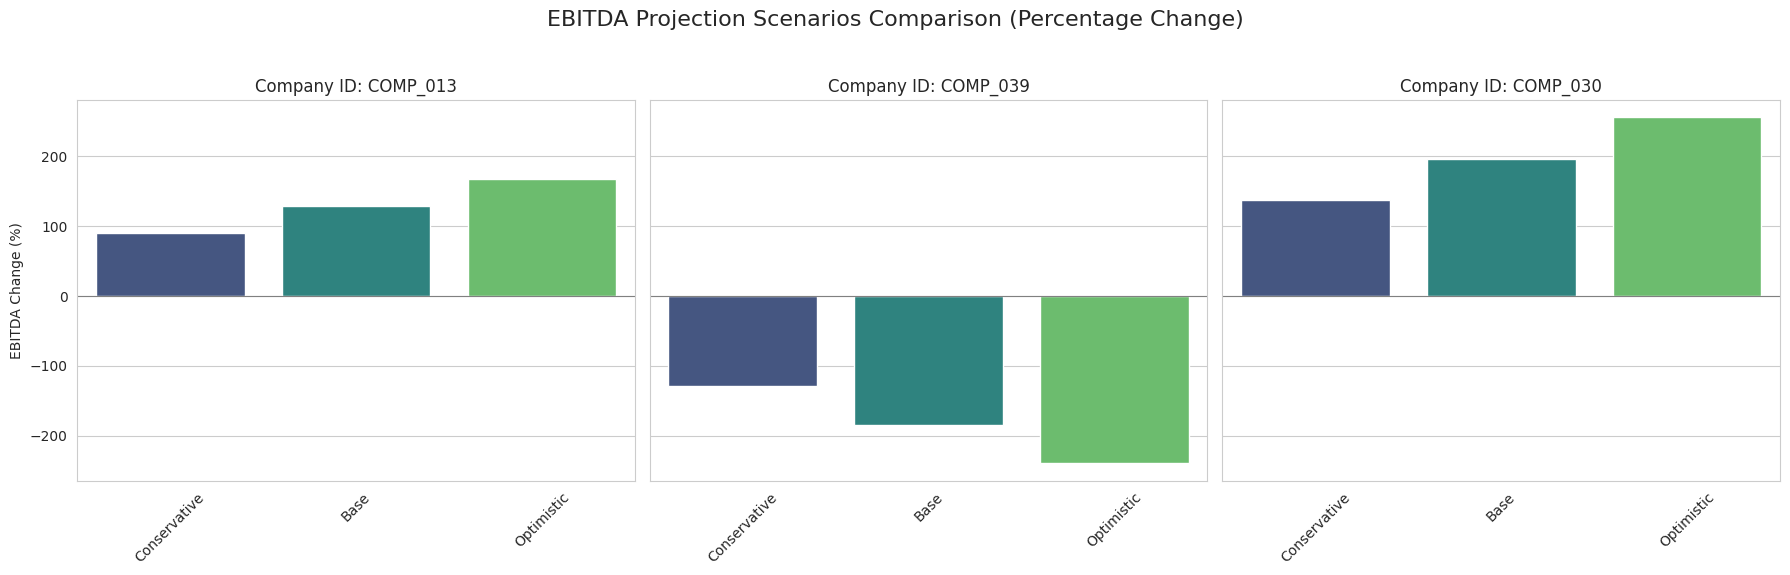

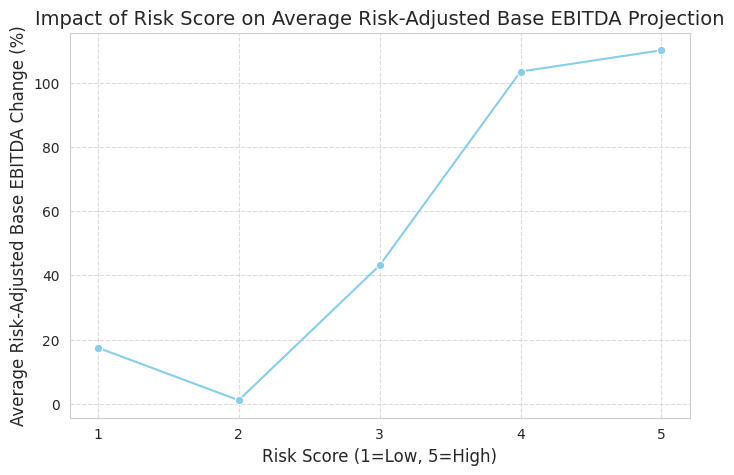

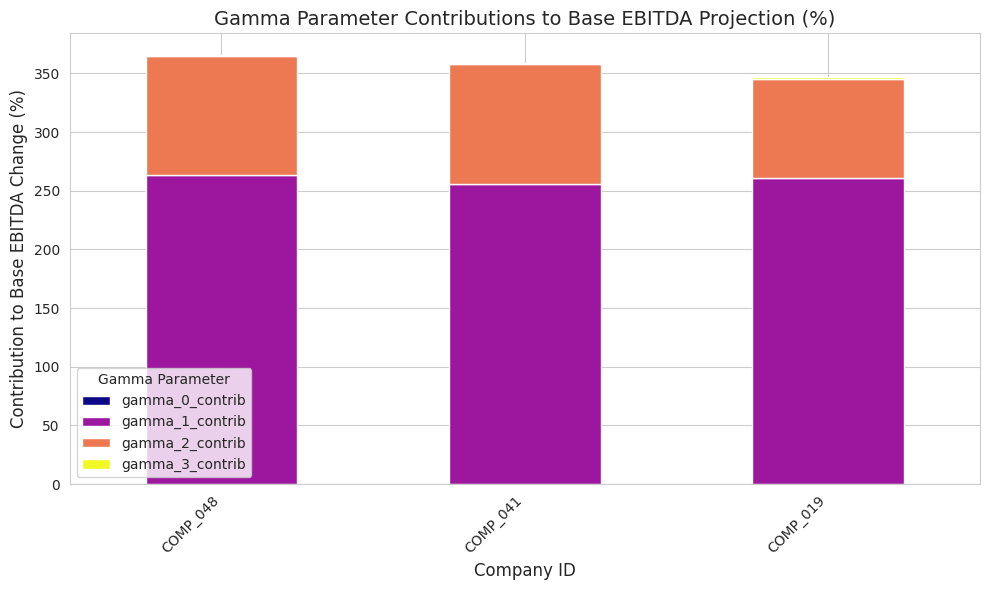

--- Summary Table of Calculated EBITDA Projections (Selected Columns) ---


,company_id,delta_air,h_r_score,risk_score,base_pct,risk_adjusted_base_pct,requires_approval,approval_reason
48,COMP_048,52.651061,77.047799,5,365.921515,292.737212,True,Projected EBITDA impact (365.9%) exceeds HITL ...
41,COMP_041,51.093253,80.125656,5,359.063279,287.250623,True,Projected EBITDA impact (359.1%) exceeds HITL ...
19,COMP_019,52.070885,65.378546,3,346.712391,346.712391,True,Projected EBITDA impact (346.7%) exceeds HITL ...
17,COMP_017,52.240928,61.584356,5,342.885241,274.308193,True,Projected EBITDA impact (342.9%) exceeds HITL ...
44,COMP_044,49.470431,74.653311,5,340.930443,272.744354,True,Projected EBITDA impact (340.9%) exceeds HITL ...
49,COMP_049,50.488287,66.034944,2,337.041214,370.745336,True,Projected EBITDA impact (337.0%) exceeds HITL ...
15,COMP_015,51.081923,62.888859,3,336.971709,336.971709,True,Projected EBITDA impact (337.0%) exceeds HITL ...
46,COMP_046,48.495246,61.121687,3,317.829013,317.829013,True,Projected EBITDA impact (317.8%) exceeds HITL ...
27,COMP_027,47.193099,65.522814,4,314.521109,283.068998,True,Projected EBITDA impact (314.5%) exceeds HITL ...
32,COMP_032,45.056362,65.727879,4,300.568284,270.511456,True,Projected EBITDA impact (300.6%) exceeds HITL ...


In [ ]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Bar charts comparing Conservative, Base, and Optimistic EBITDA projections
selected_companies = projection_results_df.sample(3, random_state=42) # Select 3 random companies

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('EBITDA Projection Scenarios Comparison (Percentage Change)', fontsize=16)

for i, (idx, row) in enumerate(selected_companies.iterrows()):
 scenario_data = [row['conservative_pct'], row['base_pct'], row['optimistic_pct']]
 scenarios = ['Conservative', 'Base', 'Optimistic']

 sns.barplot(x=scenarios, y=scenario_data, ax=axes[i], palette='viridis')
 axes[i].set_title(f"Company ID: {row['company_id']}")
 axes[i].set_ylabel("EBITDA Change (%)")
 axes[i].tick_params(axis='x', rotation=45)
 axes[i].axhline(0, color='grey', linewidth=0.8) # Add a zero line

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Plot the effect of varying risk_score values on risk_adjusted_base_pct
# Calculate average risk-adjusted base percentage for each risk score
avg_risk_adjusted = projection_results_df.groupby('risk_score')['risk_adjusted_base_pct'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='risk_score', y='risk_adjusted_base_pct', data=avg_risk_adjusted, marker='o', color='skyblue')
plt.title('Impact of Risk Score on Average Risk-Adjusted Base EBITDA Projection', fontsize=14)
plt.xlabel('Risk Score (1=Low, 5=High)', fontsize=12)
plt.ylabel('Average Risk-Adjusted Base EBITDA Change (%)', fontsize=12)
plt.xticks(avg_risk_adjusted['risk_score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Bar charts showing the contribution of each gamma parameter
selected_contrib_companies = projection_results_df.sort_values(by='base_pct', ascending=False).head(3) # Top 3 highest projections

gamma_cols = ['gamma_0_contrib', 'gamma_1_contrib', 'gamma_2_contrib', 'gamma_3_contrib']
contrib_df = selected_contrib_companies[['company_id'] + gamma_cols].set_index('company_id')

contrib_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='plasma')
plt.title('Gamma Parameter Contributions to Base EBITDA Projection (%)', fontsize=14)
plt.xlabel('Company ID', fontsize=12)
plt.ylabel('Contribution to Base EBITDA Change (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gamma Parameter')
plt.tight_layout()
plt.show()

# Display a summary table of calculated EBITDA projections, including risk adjustments and approval status.
print("--- Summary Table of Calculated EBITDA Projections (Selected Columns) ---")
display(projection_results_df[[ 'company_id', 'delta_air', 'h_r_score', 'risk_score', 'base_pct', 'risk_adjusted_base_pct', 'requires_approval', 'approval_reason' ]].sort_values(by='base_pct', ascending=False).head(10))

These visualizations provide Alex with immediate insights. The scenario comparison confirms that the conservative and optimistic bounds are appropriately set. The risk score plot clearly shows how risk assessments directly impact the adjusted projection, underscoring the model's ability to factor in different risk profiles. Finally, the gamma contribution breakdown offers transparency into *why* a particular projection was reached, which is invaluable for explaining the model to financial analysts and debugging. The summary table consolidates key information for easy reference and audit.

## 6. Preparing for Real-Time Dashboard Updates

QuantAlpha aims to provide real-time updates of company projections to their portfolio managers via dashboards. While this notebook won't host a live WebSocket server, Alex must ensure that the calculated `EBITDAProjection` data can be seamlessly transformed into a JSON-serializable format suitable for WebSocket transmission. This involves defining the structure of the messages that would be broadcast. This design step ensures that the model's output is production-ready for integration with real-time monitoring systems.

For demonstration, Alex will define the classes and functions that would manage WebSocket connections and broadcast updates, as per the system's design. This includes the `ConnectionManager` and helper functions for broadcasting specific types of updates.

In [ ]:
# Helper function to prepare projection data for JSON serialization
def prepare_for_websocket_broadcast(projection: EBITDAProjection) -> Dict[str, Any]:
    """
    Converts an EBITDAProjection object into a dictionary suitable for JSON serialization
    and WebSocket broadcast.
    """
    return {
          "type": "ebitda_projection_update", # Type of event for the dashboard to interpret
        "company_id": projection.company_id,
        "delta_air": float(projection.delta_air),
        "h_r_score": float(projection.h_r_score),
        "risk_score": projection.risk_score,
        "conservative_pct": float(projection.conservative_pct * 100),
        "base_pct": float(projection.base_pct * 100),
        "optimistic_pct": float(projection.optimistic_pct * 100),
        "risk_adjusted_base_pct": float(projection.risk_adjusted_base_pct * 100),
        "requires_approval": projection.requires_approval,
        "approval_reason": projection.approval_reason,
        "parameter_version": projection.parameter_version,
        "calculation_details": {k: float(v) if isinstance(v, Decimal) else v for k, v in projection.calculation_details.items()},
        "timestamp": pd.Timestamp.now().isoformat() # Add a timestamp for real-time context
    }

# Demonstrate preparing data for broadcast using a sample projection
sample_projection_for_ws = projections[0] # Take the first projection from the list
ws_message_data = prepare_for_websocket_broadcast(sample_projection_for_ws)

print("--- Sample JSON-ready message for WebSocket broadcast ---")
print(json.dumps(ws_message_data, indent=2))

# --- Design of WebSocket Real-Time Update System (as per provided content) ---
# Note: These classes/functions are for design illustration and will not run a live server in this notebook.

class ConnectionManager:
    """Manages WebSocket connections by topic."""
    def __init__(self):
        self._connections: Dict[str, Set[Any]] = {}

    async def connect(self, websocket: Any, topic: str):
        """Accepts a new WebSocket connection and adds it to a topic."""
        # await websocket.accept() # This would be called in a real WebSocket handler
        if topic not in self._connections:
            self._connections[topic] = set()
        self._connections[topic].add(websocket)
        print(f"WS: Connected to topic '{topic}'") # Simplified log

    def disconnect(self, websocket: Any, topic: str):
        """Removes a WebSocket connection from a topic."""
        if topic in self._connections:
            self._connections[topic].discard(websocket)
            print(f"WS: Disconnected from topic '{topic}'") # Simplified log

    async def broadcast(self, topic: str, message: dict):
        """Broadcasts a message to all subscribers of a given topic."""
        if topic not in self._connections:
            return

        disconnected = set()
        for ws in self._connections[topic]:
            try:
                # await ws.send_json(message) # This would send the message in a real environment
                print(f"WS: Broadcasting to topic '{topic}': {json.dumps(message)[:100]}...") # Simplified log
            except Exception: # Catch specific WebSocket errors in a real system
                disconnected.add(ws)

        for ws in disconnected:
            self._connections[topic].discard(ws)
            print(f"WS: Cleaned up disconnected client from topic '{topic}'")

# Initialize a dummy manager for design context
manager = ConnectionManager()

async def broadcast_score_update(company_id: str, new_score: float, old_score: float):
    """Broadcast score update to subscribers."""
    message = {
          "type": "score_update",
        "company_id": company_id,
        "new_score": new_score,
        "old_score": old_score,
        "delta": new_score - old_score,
        "timestamp": pd.Timestamp.now().isoformat()
    }
    # await manager.broadcast(f"company:{company_id}", message) # Would call this in a real app
    print(f"WS Design: Preparing to broadcast score update for company:{company_id}")

async def broadcast_fund_update(fund_id: str, fund_air: float):
    """Broadcast fund-level update."""
    message = {
          "type": "fund_air_update",
        "fund_id": fund_id,
        "fund_air_score": fund_air,
        "timestamp": pd.Timestamp.now().isoformat()
    }
    # await manager.broadcast(f"portfolio:{fund_id}", message) # Would call this in a real app
    print(f"WS Design: Preparing to broadcast fund update for portfolio:{fund_id}")

# Simulate a broadcast of our EBITDA projection update
print("--- Simulating a specific projection broadcast ---")
await manager.broadcast(f"company:{ws_message_data['company_id']}", ws_message_data)

--- Sample JSON-ready message for WebSocket broadcast ---
{
  "type": "ebitda_projection_update",
  "company_id": "COMP_000",
  "delta_air": 30.67279810820091,
  "h_r_score": 74.79377583030589,
  "risk_score": 5,
  "conservative_pct": 148.37714513008086,
  "base_pct": 211.9673501858298,
  "optimistic_pct": 275.5575552415787,
  "risk_adjusted_base_pct": 169.57388014866382,
  "requires_approval": true,
  "approval_reason": "Projected EBITDA impact (212.0%) exceeds HITL threshold (15.0%)",
  "parameter_version": "v2.0",
  "calculation_details": {
    "gamma_0_contrib": 0.0025,
    "gamma_1_contrib": 1.5336399054100456,
    "gamma_2_contrib": 0.5735335964482524,
    "gamma_3_contrib": 0.01,
    "step_up_triggered": true
  },
  "timestamp": "2026-03-23T13:10:41.177620"
}
--- Simulating a specific projection broadcast ---


By explicitly defining the `prepare_for_websocket_broadcast` function, Alex ensures that the output from the `EBITDACalculator` is structured correctly for real-time consumption. The `ConnectionManager` and associated broadcast functions illustrate the architectural design for handling real-time data flows, which is a critical component for QuantAlpha's interactive dashboards. This completes Alex's task of implementing and validating the EBITDA v2.0 model, preparing its outputs for both analytical review and real-time operational use.

## QuantUniversity License

© QuantUniversity 2025  
This notebook was created for **educational purposes only** and is **not intended for commercial use**.  

- You **may not copy, share, or redistribute** this notebook **without explicit permission** from QuantUniversity.  
- You **may not delete or modify this license cell** without authorization.  
- This notebook was generated using **QuCreate**, an AI-powered assistant.  
- Content generated by AI may contain **hallucinated or incorrect information**. Please **verify before using**.  

All rights reserved. For permissions or commercial licensing, contact: [info@qusandbox.com](mailto:info@qusandbox.com)